In [ ]:
import os
import sys 
import glob 
import re
import cv2  
import logging

import torch
import numpy as np
import matplotlib.pyplot as plt 
import torch.nn as nn
import pickle as pkl

from PIL import Image
from torch.utils.data import DataLoader, Dataset 

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
    )


In [45]:
class ADE20KLoader(Dataset): 
    def __init__(
            self,
            split: str = 'validation',
            images_fp: str = r'C:\Users\ADMIN\Documents\SAM\Research\src\Data\ADE20K\ADEChallengeData2016\images',
            annotations_fp: str = r'C:\Users\ADMIN\Documents\SAM\Research\src\Data\ADE20K\ADEChallengeData2016\annotations',
            index_fp: str = r'C:\Users\ADMIN\Documents\SAM\Research\src\Data\ADE20K\index_ade20k.pkl'
            ):
        super().__init__()
        assert split in ("training", "validation"), "split must be 'training' or 'validation'"
        self.split = split
        self.images_fp = os.path.join(images_fp, split)
        self.annotations_fp = os.path.join(annotations_fp, split)

        # Load class index: maps integer class id -> human-readable label
        if os.path.exists(index_fp):
            with open(index_fp, 'rb') as f:
                index = pkl.load(f)
            # index['objectnames'] is a list of 150 class name strings (1-indexed)
            self.class_names = ['background'] + list(index['objectnames'])
        else:
            logging.warning("index_ade20k.pkl not found — class labels will fall back to numeric ids.")
            self.class_names = None

        # Collect all image paths recursively (images are nested by scene category)
        self.image_paths = sorted(glob.glob(
            os.path.join(self.images_fp, '**', '*.jpg'), recursive=True
        ))
        if len(self.image_paths) == 0:
            raise FileNotFoundError(f"No images found under {self.images_fp}")

        logging.info("ADE20KLoader | split=%s | images found=%d", split, len(self.image_paths))

    def __len__(self):
        return len(self.image_paths)

    def _decode_segmentation(self, seg_path: str):
        """
        Decode an ADE20K *_seg.png into per-instance masks, bounding boxes, and labels.

        ADE20K segmentation encoding (RGB):
            - Class index  : Blue  channel (1-indexed; 0 = background)
            - Instance idx : (Red // 10) * 256 + Green
        
        Returns:
            labels (List[str])         : class name per instance
            bounding_boxes (List[np.ndarray]) : [x_min, y_min, x_max, y_max] per instance
            masks (List[np.ndarray])   : binary boolean mask per instance
        """
        seg = np.array(Image.open(seg_path).convert('RGB'))
        R, G, B = seg[:, :, 0], seg[:, :, 1], seg[:, :, 2]

        class_map    = B.astype(np.int32)                          # H x W, values 0-150
        instance_map = (R.astype(np.int32) // 10) * 256 + G.astype(np.int32)  # H x W

        labels, bounding_boxes, masks = [], [], []

        unique_instances = np.unique(instance_map)
        unique_instances = unique_instances[unique_instances != 0]  # drop background

        for inst_id in unique_instances:
            inst_mask = instance_map == inst_id                     # boolean H x W

            # Derive class from the most common class value within this instance
            class_ids_in_inst = class_map[inst_mask]
            class_id = int(np.bincount(class_ids_in_inst).argmax())

            if class_id == 0:
                continue  # skip background-only instances

            # Resolve label string
            if self.class_names and class_id < len(self.class_names):
                label = self.class_names[class_id]
            else:
                label = str(class_id)

            # Bounding box from mask extents
            rows = np.any(inst_mask, axis=1)
            cols = np.any(inst_mask, axis=0)
            y_min, y_max = np.where(rows)[0][[0, -1]]
            x_min, x_max = np.where(cols)[0][[0, -1]]

            labels.append(label)
            bounding_boxes.append(np.array([x_min, y_min, x_max, y_max]))
            masks.append(inst_mask)

        return labels, bounding_boxes, masks

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image_id   = os.path.splitext(os.path.basename(image_path))[0]
        
        # Derive annotation path: same relative sub-path, suffix _seg.png
        rel_path   = os.path.relpath(image_path, self.images_fp)
        
        seg_path   = os.path.join(
            self.annotations_fp,
            os.path.dirname(rel_path),
            image_id + '.png'
        )
        

        if not os.path.exists(image_path):
            raise FileNotFoundError(f"Image not found: {image_path}")
        if not os.path.exists(seg_path):
            raise FileNotFoundError(f"Segmentation mask not found: {seg_path}")

        image          = np.array(Image.open(image_path).convert('RGB'))
        canvas_height, canvas_width = image.shape[:2]

        labels, bounding_boxes, masks = self._decode_segmentation(seg_path)

        return {
            'image_id'      : image_id,
            'image'         : image,
            'canvas_height' : canvas_height,
            'canvas_width'  : canvas_width,
            'labels'        : labels,
            'bounding_boxes': bounding_boxes,
            'masks'         : masks
        }

In [46]:
ade_dataset = ADE20KLoader()

2026-03-23 21:52:34,322 - WARNING - index_ade20k.pkl not found — class labels will fall back to numeric ids.
2026-03-23 21:52:34,333 - INFO - ADE20KLoader | split=validation | images found=2000


In [47]:
first_sample = ade_dataset[0]
first_sample

{'image_id': 'ADE_val_00000001',
 'image': array([[[ 86, 138, 186],
         [ 85, 137, 185],
         [ 85, 137, 187],
         ...,
         [ 78, 129, 186],
         [ 78, 129, 186],
         [ 78, 129, 186]],
 
        [[ 86, 138, 186],
         [ 85, 137, 185],
         [ 85, 137, 187],
         ...,
         [ 78, 129, 186],
         [ 78, 129, 186],
         [ 78, 129, 186]],
 
        [[ 86, 138, 186],
         [ 85, 137, 185],
         [ 85, 137, 187],
         ...,
         [ 78, 129, 186],
         [ 78, 129, 186],
         [ 78, 129, 186]],
 
        ...,
 
        [[ 89,  96,  55],
         [ 92,  99,  58],
         [ 92,  99,  58],
         ...,
         [114, 111, 104],
         [114, 111, 104],
         [115, 112, 103]],
 
        [[ 94, 100,  62],
         [ 95, 101,  63],
         [ 94, 100,  62],
         ...,
         [117, 114, 107],
         [118, 115, 108],
         [119, 116, 107]],
 
        [[ 94, 100,  62],
         [ 94, 100,  62],
         [ 91,  97,  59],


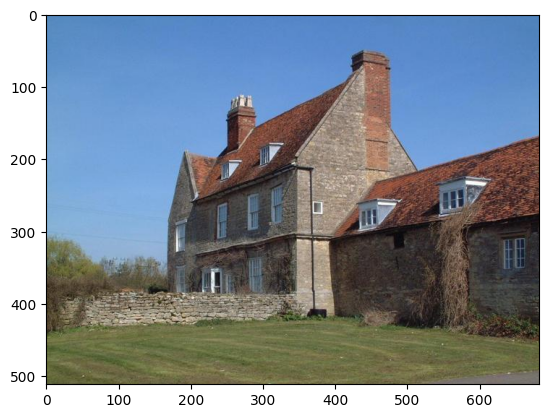

In [48]:
image = first_sample['image'] 
plt.imshow(image)

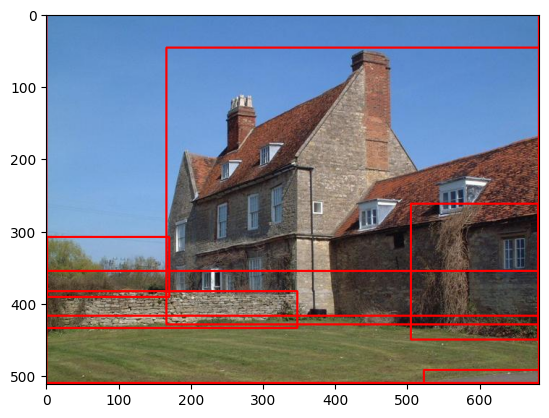

In [66]:
x_min, y_min, x_max, y_max = first_sample['bounding_boxes'][6] 
cv2.rectangle(img=image, pt1=(x_min, y_min), pt2=(x_max, y_max), color=(255, 0, 0), thickness=2)
plt.imshow(image)

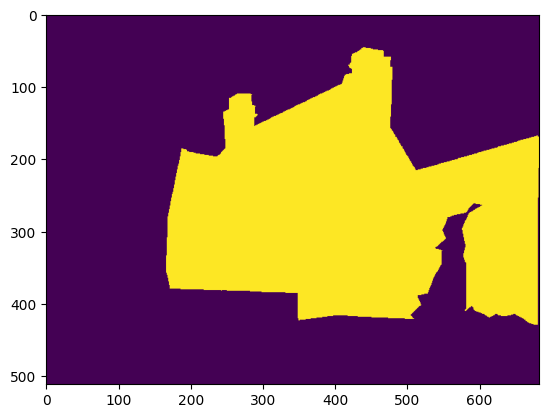

In [71]:
overlay = np.zeros(shape=(512, 683), dtype=np.int8)
mask = first_sample['masks'][1]
overlay[mask] = 1 
plt.imshow(overlay)